# Constrained HDBSCAN Benchmark: 4 Methods × 7 Geometries

Performance and clustering-quality comparison of constrained vs unconstrained HDBSCAN implementations.

**4 Methods:**
| # | Method | MST | Constraints | Input |
|---|--------|-----|-------------|-------|
| 1 | **New Borůvka (constrained)** | `boruvka_constrained_new.py` — KD-tree accelerated | ✅ CL | raw points |
| 2 | **New Borůvka (no constraints)** | same code, empty CSR | ❌ | raw points |
| 3 | **Kruskal (constrained)** | `hdbscan_cannotLink.py` | ✅ CL | precomputed dist |
| 4 | **Original fast_hdbscan** | `boruvka.py` | ❌ | raw points |

**7 Geometries** (all with intra-class adversarial cannot-link constraints):
1. Two Moons — classic non-convex benchmark
2. Spiral — Archimedean spiral
3. Concentric Rings — nested circles
4. Figure-8 (Lemniscate) — two lobes, shared pinch point
5. Swiss Roll (2-D) — band-like manifold
6. Pinwheel — galaxy-arm clusters
7. T-Shape — stem + crossbar

**Sizes**: 100 → 1,000 points (step 100)

In [10]:
# Setup: Imports and path configuration
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import numba
import scipy.sparse as sp
from sklearn.datasets import make_moons, make_blobs
from sklearn.metrics import pairwise_distances, adjusted_rand_score, normalized_mutual_info_score, v_measure_score
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict, Any
import time
import warnings
warnings.filterwarnings('ignore')

# ── New constrained Borůvka (KD-tree accelerated, our new implementation) ──
from fast_hdbscan.boruvka_constrained_new import parallel_boruvka as constrained_parallel_boruvka
from fast_hdbscan.numba_kdtree import build_kdtree

# ── Original fast_hdbscan (unconstrained KD-tree Borůvka) ──
from fast_hdbscan.hdbscan import (
    fast_hdbscan as original_fast_hdbscan,
    clusters_from_spanning_tree,
)

# ── Kruskal constrained (from hdbscan_cannotLink, precomputed distances) ──
from fast_hdbscan.hdbscan_cannotLink import (
    fast_hdbscan_precomputed_with_cannot_link,
)

print(f"Project root: {project_root}")
print("✓ Imports successful!")
print(f"  • constrained_parallel_boruvka  (boruvka_constrained_new.py)")
print(f"  • original_fast_hdbscan         (hdbscan.py / boruvka.py)")
print(f"  • fast_hdbscan_precomputed_with_cannot_link (hdbscan_cannotLink.py)")

Project root: /Users/kareefullah/Desktop/Rich Projects/fast_hdbscan
✓ Imports successful!
  • constrained_parallel_boruvka  (boruvka_constrained_new.py)
  • original_fast_hdbscan         (hdbscan.py / boruvka.py)
  • fast_hdbscan_precomputed_with_cannot_link (hdbscan_cannotLink.py)


## 2. Dataset Generation

In [11]:
# =============================================================================
# GEOMETRY GENERATORS  (7 types — all use intra-class cannot-link constraints)
# =============================================================================

def generate_two_moons(n_samples: int, noise: float = 0.1, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate a two moons dataset for clustering demonstration.

    Two moons is a classic non-convex clustering benchmark where two
    interleaving half-circle shapes cannot be separated by linear methods.

    Visual representation:
    ┌─────────────────────────────┐
    │       ●●●●●●●●●             │
    │     ●●         ●●           │
    │    ●             ●          │
    │   ●               ●         │
    │         ●●●●●●●●●●          │
    │       ●●         ●●         │
    │      ●             ●        │
    └─────────────────────────────┘

    Args:
        n_samples: Total number of points (split evenly between moons).
        noise: Standard deviation of Gaussian noise added to points.
        random_state: Seed for reproducibility.

    Returns:
        X: Array of shape (n_samples, 2) with point coordinates.
        y: Array of shape (n_samples,) with ground truth labels (0 or 1).
    """
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    return X.astype(np.float64), y.astype(np.int32)


def generate_spiral(
    n_samples: int,
    noise: float = 0.3,
    n_turns: float = 2.0,
    random_state: int = 42
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate a single spiral dataset.

    Creates points along an Archimedean spiral, which is useful for testing
    how well algorithms handle long, winding manifold structures.

    Visual representation:
    ┌─────────────────────────────┐
    │              ●●●            │
    │            ●●   ●●          │
    │          ●●       ●●        │
    │         ●     ○○○   ●       │
    │        ●    ○○   ○○  ●      │
    │       ●    ○       ○  ●     │
    │       ●   ○   ···   ○  ●    │
    │       ●   ○  ·   ·  ○  ●    │
    │       ●    ○○     ○○   ●    │
    │        ●    ○○○○○○    ●     │
    │         ●            ●      │
    │          ●●●●●●●●●●●●       │
    └─────────────────────────────┘
         Inner (○) vs Outer (●)

    Args:
        n_samples: Total number of points.
        noise: Gaussian noise standard deviation.
        n_turns: Number of complete spiral rotations.
        random_state: Seed for reproducibility.

    Returns:
        X: Array of shape (n_samples, 2) with point coordinates.
        y: Array of shape (n_samples,) with position-based labels (inner/outer halves).
    """
    rng = np.random.RandomState(random_state)

    # Parametric spiral: r = t, theta = 2*pi*n_turns*t
    t = np.linspace(0.3, 1.0, n_samples)
    theta = 2 * np.pi * n_turns * t

    x = t * np.cos(theta)
    y_coord = t * np.sin(theta)

    # Add noise
    x += rng.normal(0, noise * 0.1, n_samples)
    y_coord += rng.normal(0, noise * 0.1, n_samples)

    X = np.column_stack([x, y_coord]).astype(np.float64)

    # Label: inner half (0) vs outer half (1)
    y = (t > 0.65).astype(np.int32)

    return X, y


def generate_concentric_rings(
    n_samples: int,
    noise: float = 0.05,
    factor: float = 0.5,
    random_state: int = 42
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate two concentric rings (circles) dataset.

    This is a classic non-linear clustering challenge where an inner ring
    is surrounded by an outer ring.

    Visual representation:
    ┌─────────────────────────────┐
    │       ●●●●●●●●●             │
    │     ●●         ●●           │
    │    ●    ○○○○○    ●          │
    │   ●   ○○     ○○   ●         │
    │   ●   ○       ○   ●         │
    │   ●   ○○     ○○   ●         │
    │    ●    ○○○○○    ●          │
    │     ●●         ●●           │
    │       ●●●●●●●●●             │
    └─────────────────────────────┘
         ○ = Inner Ring (class 0)
         ● = Outer Ring (class 1)

    Args:
        n_samples: Total number of points (split between rings).
        noise: Gaussian noise standard deviation added to points.
        factor: Ratio of inner to outer ring radius (0 < factor < 1).
        random_state: Seed for reproducibility.

    Returns:
        X: Array of shape (n_samples, 2) with point coordinates.
        y: Array of shape (n_samples,) with labels (0=inner, 1=outer).
    """
    from sklearn.datasets import make_circles
    X, y = make_circles(n_samples=n_samples, factor=factor, noise=noise,
                       random_state=random_state)
    return X.astype(np.float64), y.astype(np.int32)


# =============================================================================
# NEW GEOMETRIES
# =============================================================================

def generate_figure_eight(
    n_samples: int,
    noise: float = 0.06,
    random_state: int = 42,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate a figure-8 (lemniscate) dataset with 2 lobes.

    The figure-8 creates two lobes that share a pinch point at the origin.
    Each lobe is a separate class.  The shared pinch makes this geometry
    tricky — nearby points from different lobes are very close together.

    Visual representation:
    ┌─────────────────────────────┐
    │        ○○○○          ●●●●   │
    │      ○○    ○○      ●●    ●● │
    │     ○        ○    ●        ●│
    │      ○○    ○○  ··  ●●    ●● │
    │        ○○○○    ··    ●●●●   │
    └─────────────────────────────┘
        ○ = Left lobe (class 0)
        ● = Right lobe (class 1)
        · = Pinch point (origin)

    Args:
        n_samples: Total number of points.
        noise: Gaussian noise standard deviation.
        random_state: Seed for reproducibility.

    Returns:
        X: shape (n_samples, 2)
        y: shape (n_samples,), labels 0 (left lobe) / 1 (right lobe)
    """
    rng = np.random.RandomState(random_state)
    n_each = n_samples // 2

    # Left lobe: circle centred at (-1, 0) with radius 1
    theta_left = np.linspace(0, 2 * np.pi, n_each, endpoint=False)
    left_x = -1.0 + np.cos(theta_left)
    left_y = np.sin(theta_left)

    # Right lobe: circle centred at (+1, 0) with radius 1
    n_right = n_samples - n_each
    theta_right = np.linspace(0, 2 * np.pi, n_right, endpoint=False)
    right_x = 1.0 + np.cos(theta_right)
    right_y = np.sin(theta_right)

    X = np.vstack([
        np.column_stack([left_x, left_y]),
        np.column_stack([right_x, right_y]),
    ]).astype(np.float64)
    X += rng.normal(0, noise, X.shape)

    y = np.array([0] * n_each + [1] * n_right, dtype=np.int32)

    perm = rng.permutation(len(y))
    return X[perm], y[perm]


def generate_swiss_roll(
    n_samples: int,
    noise: float = 0.4,
    random_state: int = 42,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate a 2-D "Swiss roll" (unwound spiral with width).

    Unlike the thin Archimedean spiral, the Swiss roll has measurable
    thickness, producing a band that rolls around the origin.  Points
    are labelled by their radial position (inner band = 0, outer band = 1).

    Visual representation:
    ┌──────────────────────────────┐
    │          ●●●●●●●●●           │
    │        ●●         ●●         │
    │       ●   ○○○○○○○   ●       │
    │      ●  ○○       ○○  ●      │
    │     ●  ○    ···    ○  ●     │
    │      ●  ○○       ○○  ●      │
    │       ●   ○○○○○○○   ●       │
    │        ●●         ●●         │
    │          ●●●●●●●●●           │
    └──────────────────────────────┘
        ○ = Inner band (class 0)
        ● = Outer band (class 1)

    Args:
        n_samples: Total number of points.
        noise: Controls band width (radial jitter).
        random_state: Seed for reproducibility.

    Returns:
        X: shape (n_samples, 2)
        y: shape (n_samples,), labels 0 (inner) / 1 (outer)
    """
    rng = np.random.RandomState(random_state)

    t = np.sort(rng.uniform(1.5 * np.pi, 4.5 * np.pi, n_samples))
    # Radial jitter gives the roll its width
    r = t + rng.normal(0, noise, n_samples)

    x = r * np.cos(t)
    y_coord = r * np.sin(t)

    X = np.column_stack([x, y_coord]).astype(np.float64)

    # Label by parameter position (inner vs outer half of the unrolled band)
    mid = (t.min() + t.max()) / 2.0
    y = (t > mid).astype(np.int32)

    return X, y


def generate_pinwheel(
    n_samples: int,
    n_arms: int = 5,
    noise: float = 0.08,
    random_state: int = 42,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate a pinwheel / galaxy-arms dataset.

    Points are arranged in ``n_arms`` curved arms radiating from a shared
    centre.  Each arm is a separate class.  The arms spiral outward,
    creating overlapping density ridges that are hard for distance-only
    methods to separate.

    Visual representation (3-arm example):
    ┌──────────────────────────────┐
    │           ●●●                │
    │          ●●  ●               │
    │    ○○   ●     ●              │
    │   ○○  ·· ··    ●             │
    │  ○○  ··    ··   △△           │
    │    ○       ··    △△          │
    │     ○        ··   △△         │
    │              ··    △△        │
    └──────────────────────────────┘
        Each symbol = one arm / class

    Args:
        n_samples: Total number of points.
        n_arms: Number of spiral arms (= number of classes).
        noise: Gaussian noise scale.
        random_state: Seed for reproducibility.

    Returns:
        X: shape (n_samples, 2)
        y: shape (n_samples,), labels 0 … n_arms-1
    """
    rng = np.random.RandomState(random_state)
    n_per_arm = n_samples // n_arms
    remainder = n_samples - n_per_arm * n_arms

    all_x, all_y, all_labels = [], [], []

    for arm_idx in range(n_arms):
        n_this = n_per_arm + (1 if arm_idx < remainder else 0)
        # Radial parameter
        r = np.linspace(0.3, 1.0, n_this)
        # Angle offset per arm + spiral twist
        base_angle = 2 * np.pi * arm_idx / n_arms
        theta = base_angle + 1.0 * np.pi * r  # 1 half-turn of twist

        x = r * np.cos(theta)
        y_coord = r * np.sin(theta)

        # Add noise perpendicular & radial
        x += rng.normal(0, noise, n_this)
        y_coord += rng.normal(0, noise, n_this)

        all_x.append(x)
        all_y.append(y_coord)
        all_labels.extend([arm_idx] * n_this)

    X = np.column_stack([np.concatenate(all_x), np.concatenate(all_y)]).astype(np.float64)
    y = np.array(all_labels, dtype=np.int32)

    perm = rng.permutation(len(y))
    return X[perm], y[perm]


def generate_t_shape(
    n_samples: int,
    noise: float = 0.08,
    random_state: int = 42,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate a T-shaped dataset (stem + crossbar).

    The T has two parts (classes):
      - class 0 = horizontal crossbar
      - class 1 = vertical stem

    The two parts share a junction region, making it hard for algorithms
    to decide which points belong to which part.

    Visual representation:
    ┌──────────────────────────────┐
    │   ○○○○○○○○○○○○○○○○○○○○       │
    │          ●●                   │
    │          ●●                   │
    │          ●●                   │
    │          ●●                   │
    │          ●●                   │
    └──────────────────────────────┘
        ○ = Crossbar (class 0)
        ● = Stem    (class 1)

    Args:
        n_samples: Total number of points.
        noise: Gaussian noise standard deviation.
        random_state: Seed for reproducibility.

    Returns:
        X: shape (n_samples, 2)
        y: shape (n_samples,), labels 0 (crossbar) / 1 (stem)
    """
    rng = np.random.RandomState(random_state)
    n_bar = n_samples // 2
    n_stem = n_samples - n_bar

    # Crossbar: horizontal band at y ≈ 1.5,  x ∈ [-2, 2]
    bar_x = rng.uniform(-2.0, 2.0, n_bar)
    bar_y = rng.normal(1.5, noise, n_bar)

    # Stem: vertical band at x ≈ 0,  y ∈ [-1.5, 1.5]
    stem_x = rng.normal(0.0, noise, n_stem)
    stem_y = rng.uniform(-1.5, 1.5, n_stem)

    X = np.vstack([
        np.column_stack([bar_x, bar_y]),
        np.column_stack([stem_x, stem_y]),
    ]).astype(np.float64)
    y = np.array([0] * n_bar + [1] * n_stem, dtype=np.int32)

    perm = rng.permutation(len(y))
    return X[perm], y[perm]


# =============================================================================
# CONSTRAINT GENERATOR — INTRA-CLASS (same class, adversarial)
# =============================================================================

def generate_constraints_within_class(
    X: np.ndarray,
    y: np.ndarray,
    n_constraints: int,
    random_state: int = 42
) -> np.ndarray:
    """
    Generate cannot-link constraints between points of the SAME class (intra-class).

    This creates "adversarial" constraints that go against the ground truth,
    useful for testing robustness. Constraints are placed between same-class
    points using scaling formula: n_constraints = size // 30.

    Args:
        X: Point coordinates (used to pick distant same-class pairs).
        y: Ground truth labels array.
        n_constraints: Number of constraint pairs to generate.
        random_state: Seed for reproducibility.

    Returns:
        Array of shape (n_constraints, 2) with intra-class constraint pairs.
    """
    rng = np.random.RandomState(random_state)
    unique_labels = np.unique(y)

    constraints = set()
    max_attempts = n_constraints * 10
    attempts = 0

    while len(constraints) < n_constraints and attempts < max_attempts:
        # Pick a class
        c = rng.choice(unique_labels)
        class_indices = np.where(y == c)[0]

        if len(class_indices) < 2:
            attempts += 1
            continue

        # Pick two points from same class
        i, j = rng.choice(class_indices, 2, replace=False)

        if i > j:
            i, j = j, i
        constraints.add((i, j))
        attempts += 1

    return np.array(list(constraints), dtype=np.int32)


# =============================================================================
# CSR + DENSE CONSTRAINT HELPERS
# =============================================================================

def build_constraint_csr(n_points: int, constraints: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build CSR (Compressed Sparse Row) representation of cannot-link constraints.

    CSR format enables O(1) lookup of "which points does point i have
    constraints with?" — essential for fast constraint checking.

    Args:
        n_points: Total number of points in dataset.
        constraints: Array of shape (n_constraints, 2) with constraint pairs.

    Returns:
        cl_indptr: CSR indptr array.
        cl_indices: CSR indices array.
    """
    if len(constraints) == 0:
        indptr = np.zeros(n_points + 1, dtype=np.int64)
        indices = np.array([], dtype=np.int32)
        return indptr, indices

    # Build sparse matrix (symmetric)
    rows = np.concatenate([constraints[:, 0], constraints[:, 1]])
    cols = np.concatenate([constraints[:, 1], constraints[:, 0]])
    data = np.ones(len(rows), dtype=np.int32)

    csr = sp.csr_matrix((data, (rows, cols)), shape=(n_points, n_points))
    csr.sum_duplicates()

    return np.asarray(csr.indptr, dtype=np.int64), np.asarray(csr.indices, dtype=np.int32)


def build_constraint_matrix(n_points: int, constraints: np.ndarray) -> np.ndarray:
    """
    Build dense boolean constraint matrix for HDBSCAN API.

    Args:
        n_points: Total number of points in dataset.
        constraints: Array of shape (n_constraints, 2) with constraint pairs.

    Returns:
        Boolean array of shape (n_points, n_points).
    """
    matrix = np.zeros((n_points, n_points), dtype=bool)
    if len(constraints) > 0:
        matrix[constraints[:, 0], constraints[:, 1]] = True
        matrix[constraints[:, 1], constraints[:, 0]] = True
    return matrix


# ============================================================================
# DATASET CONFIGURATION
# ============================================================================

# TEMP: tiny sizes for quick testing (revert to range(100, 1001, 100) later)
SIZES = list(range(100, 1001, 100))  # [100, 200, ..., 1000]
VIZ_SIZES = [100, 300, 500, 1000]

print(f"Dataset sizes: {len(SIZES)} sizes from {SIZES[0]} to {SIZES[-1]}")

# ============================================================================
# GENERATE ALL DATASETS  (7 geometries × multiple sizes)
# ============================================================================

GEOMETRY_CONFIGS = [
    # (key,               generator,                extra_kwargs)
    ('two_moons',         generate_two_moons,       {}),
    ('spiral',            generate_spiral,           {}),
    ('concentric_rings',  generate_concentric_rings, {}),
    ('figure_eight',      generate_figure_eight,     {}),
    ('swiss_roll',        generate_swiss_roll,       {}),
    ('pinwheel',          generate_pinwheel,         {}),
    ('t_shape',           generate_t_shape,          {}),
]


def _pack_dataset(X, y, constraints, random_state):
    """Helper: compute distances, edge lists, CSR etc. for one (X, y, constraints)."""
    distances = pairwise_distances(X, metric='euclidean')
    n_points = X.shape[0]
    triu = np.triu_indices(n_points, k=1)
    u = triu[0].astype(np.int32)
    v = triu[1].astype(np.int32)
    w = distances[triu].astype(np.float64)
    cl_indptr, cl_indices = build_constraint_csr(n_points, constraints)
    return {
        'X': X, 'y': y, 'constraints': constraints,
        'distances': distances,
        'u': u, 'v': v, 'w': w,
        'cl_indptr': cl_indptr, 'cl_indices': cl_indices,
        'constraint_matrix': build_constraint_matrix(n_points, constraints),
    }


def generate_all_datasets(sizes: List[int], random_state: int = 42) -> Dict[str, Dict]:
    """
    Generate 7 geometry types at various sizes — ALL with intra-class constraints.

    Dataset Types:
    1. two_moons         — Two moons with intra-class constraints
    2. spiral            — Archimedean spiral with intra-class constraints
    3. concentric_rings  — Two circles with intra-class constraints
    4. figure_eight      — Two lobes (lemniscate) with intra-class constraints
    5. swiss_roll        — 2-D Swiss roll with intra-class constraints
    6. pinwheel          — Galaxy spiral arms with intra-class constraints
    7. t_shape           — T-shaped data with intra-class constraints

    Args:
        sizes: List of dataset sizes to generate.
        random_state: Seed for reproducibility.

    Returns:
        Dictionary with dataset type keys, each containing dict of sizes.
    """
    datasets: Dict[str, Dict] = {key: {} for key, _, _ in GEOMETRY_CONFIGS}

    for size in sizes:
        n_constraints = max(5, size // 30)

        for key, gen_fn, extra_kw in GEOMETRY_CONFIGS:
            X, y = gen_fn(size, random_state=random_state, **extra_kw)
            constraints = generate_constraints_within_class(X, y, n_constraints, random_state + 1)
            datasets[key][size] = _pack_dataset(X, y, constraints, random_state)

        if size % 500 == 0:
            print(f"Generated datasets for size {size}")

    return datasets


print("\nGenerating datasets...")
datasets = generate_all_datasets(VIZ_SIZES)  # Start with VIZ_SIZES for quick testing
print("\nDatasets generated for visualization sizes!")

# Show summary
for dtype, size_data in datasets.items():
    print(f"\n{dtype}:")
    for size, data in size_data.items():
        print(f"  Size {size}: {len(data['constraints'])} constraints")

Dataset sizes: 10 sizes from 100 to 1000

Generating datasets...
Generated datasets for size 500
Generated datasets for size 1000

Datasets generated for visualization sizes!

two_moons:
  Size 100: 5 constraints
  Size 300: 10 constraints
  Size 500: 16 constraints
  Size 1000: 33 constraints

spiral:
  Size 100: 5 constraints
  Size 300: 10 constraints
  Size 500: 16 constraints
  Size 1000: 33 constraints

concentric_rings:
  Size 100: 5 constraints
  Size 300: 10 constraints
  Size 500: 16 constraints
  Size 1000: 33 constraints

figure_eight:
  Size 100: 5 constraints
  Size 300: 10 constraints
  Size 500: 16 constraints
  Size 1000: 33 constraints

swiss_roll:
  Size 100: 5 constraints
  Size 300: 10 constraints
  Size 500: 16 constraints
  Size 1000: 33 constraints

pinwheel:
  Size 100: 5 constraints
  Size 300: 10 constraints
  Size 500: 16 constraints
  Size 1000: 33 constraints

t_shape:
  Size 100: 5 constraints
  Size 300: 10 constraints
  Size 500: 16 constraints
  Size 1

## 2.1 Geometry Gallery: Visual Overview of All Dataset Types

Below is a visual gallery showing each geometry with intra-class constraints overlaid as red dashed lines.

GEOMETRY GALLERY: All 7 Dataset Types (Intra-class Constraints)


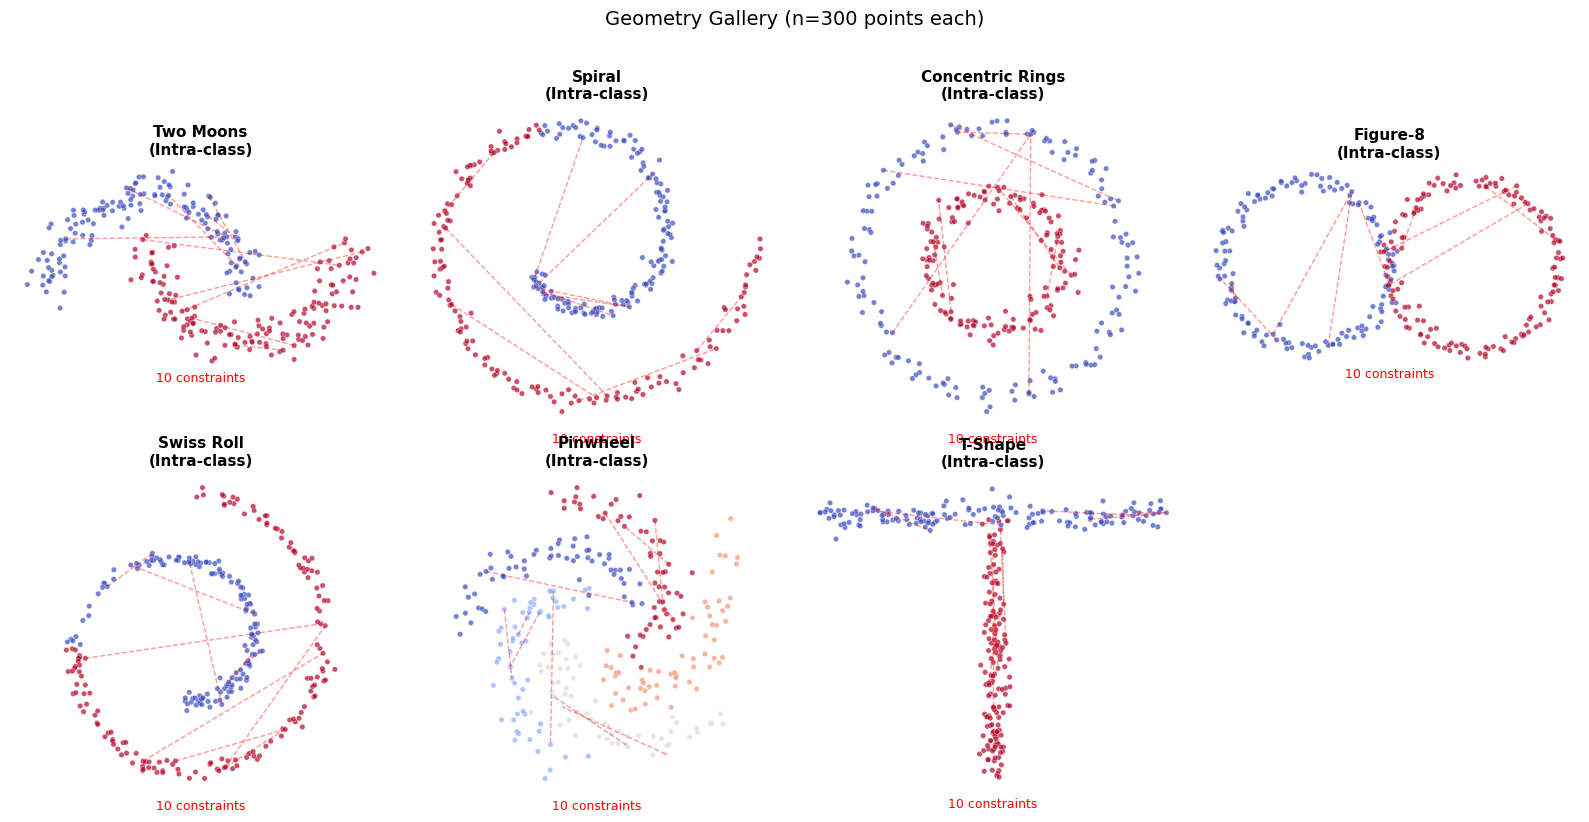

In [12]:
# =============================================================================
# GEOMETRY GALLERY: Visualize all 7 dataset types with constraints
# =============================================================================

def plot_geometry_gallery(datasets: Dict, size: int = 300) -> None:
    """
    Create a visual gallery showing all geometry types with constraints.

    Shows each dataset type with:
    - Points colored by ground truth class
    - Cannot-link constraints as red dashed lines
    """
    dataset_names = list(datasets.keys())
    n_datasets = len(dataset_names)

    # Two rows for 7 geometries: 4 on top, 3 on bottom
    n_cols = 4
    n_rows = (n_datasets + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes_flat = axes.flatten()

    # Nice display names for each geometry
    display_names = {
        'two_moons':        'Two Moons\n(Intra-class)',
        'spiral':           'Spiral\n(Intra-class)',
        'concentric_rings': 'Concentric Rings\n(Intra-class)',
        'figure_eight':     'Figure-8\n(Intra-class)',
        'swiss_roll':       'Swiss Roll\n(Intra-class)',
        'pinwheel':         'Pinwheel\n(Intra-class)',
        't_shape':          'T-Shape\n(Intra-class)',
    }

    for idx, name in enumerate(dataset_names):
        ax = axes_flat[idx]
        if size not in datasets[name]:
            # Use closest available size
            available_sizes = list(datasets[name].keys())
            use_size = min(available_sizes, key=lambda x: abs(x - 300))
        else:
            use_size = size

        data = datasets[name][use_size]
        X = data['X']
        y = data['y']
        constraints = data['constraints']

        # Plot points colored by class
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',
                            s=15, alpha=0.7, edgecolors='white', linewidths=0.3)

        # Plot constraints as red dashed lines
        if len(constraints) > 0:
            # Limit to first 20 constraints for clarity
            n_show = min(20, len(constraints))
            for i, j in constraints[:n_show]:
                ax.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]],
                       'r--', alpha=0.4, linewidth=1)

        ax.set_title(display_names.get(name, name), fontsize=11, fontweight='bold')
        ax.set_aspect('equal')
        ax.axis('off')

        # Add constraint count annotation
        ax.annotate(f'{len(constraints)} constraints',
                   xy=(0.5, -0.05), xycoords='axes fraction',
                   ha='center', fontsize=9, color='red')

    # Hide unused subplot slots
    for idx in range(n_datasets, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    plt.suptitle(f'Geometry Gallery (n={size} points each)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# Display the gallery
print("=" * 60)
print("GEOMETRY GALLERY: All 7 Dataset Types (Intra-class Constraints)")
print("=" * 60)
plot_geometry_gallery(datasets, size=300)

## 3. Comparison Harness — 4 Methods

| # | Method | MST algorithm | Constraints | Distance input |
|---|--------|---------------|-------------|----------------|
| 1 | **New Borůvka (constrained)** | `boruvka_constrained_new.parallel_boruvka` | ✅ CL | KD-tree (raw X) |
| 2 | **New Borůvka (no constraints)** | same, empty CSR | ❌ | KD-tree (raw X) |
| 3 | **Kruskal (constrained)** | `hdbscan_cannotLink` Kruskal | ✅ CL | precomputed dist |
| 4 | **Original fast_hdbscan** | `boruvka.parallel_boruvka` | ❌ | KD-tree (raw X) |

In [13]:
@dataclass
class BenchmarkResult:
    """Result from running one HDBSCAN method."""
    method_name: str
    labels: np.ndarray
    time_seconds: float
    ari_score: float
    nmi_score: float
    v_measure: float
    n_clusters: int
    n_noise: int
    error: Optional[str] = None


def _score(y_true, labels):
    """Compute ARI/NMI/V-measure ignoring noise."""
    mask = (labels >= 0) & (y_true >= 0)
    if mask.sum() == 0:
        return 0.0, 0.0, 0.0
    return (
        adjusted_rand_score(y_true[mask], labels[mask]),
        normalized_mutual_info_score(y_true[mask], labels[mask]),
        v_measure_score(y_true[mask], labels[mask]),
    )


def _result(method_name, labels, elapsed, y_true, error=None):
    if error:
        return BenchmarkResult(method_name, np.full(len(y_true), -1),
                               0.0, 0.0, 0.0, 0.0, 0, len(y_true), error)
    ari, nmi, vm = _score(y_true, labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    return BenchmarkResult(method_name, labels, elapsed, ari, nmi, vm,
                           n_clusters, n_noise)


def _pad_spanning_forest(edges: np.ndarray, n_points: int) -> np.ndarray:
    """Pad a partial MST into a full spanning tree (n-1 edges).

    When constraints prevent some components from merging, the constrained
    Borůvka returns fewer than n-1 edges (a spanning *forest*).
    ``clusters_from_spanning_tree`` derives ``n_points = n_edges + 1``
    and creates internal arrays sized for that many points, so passing
    a short edge list causes out-of-bounds memory corruption.

    This helper finds disconnected components via union-find and bridges
    them with ``np.inf``-weight sentinel edges.  The infinite weight
    ensures these bridges are cut first during condensation, so the
    resulting HDBSCAN labels treat the disconnected components as
    separate clusters (or noise).
    """
    n_edges = edges.shape[0]
    needed = n_points - 1
    if n_edges >= needed:
        return edges  # already a spanning tree

    # Simple union-find to discover components
    parent = np.arange(n_points)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb
            return True
        return False

    for i in range(n_edges):
        u, v = int(edges[i, 0]), int(edges[i, 1])
        union(u, v)

    # Find one representative per component
    roots = set()
    for i in range(n_points):
        roots.add(find(i))

    roots = sorted(roots)
    # Bridge components with inf-weight edges
    bridges = []
    for k in range(1, len(roots)):
        bridges.append([float(roots[0]), float(roots[k]), np.inf])

    if bridges:
        bridge_arr = np.array(bridges, dtype=edges.dtype)
        edges = np.vstack([edges, bridge_arr])

    return edges


# ── Method 1: New Constrained Borůvka (with CL constraints) ─────────────────
def run_new_boruvka_constrained(
    X: np.ndarray,
    cl_indptr: np.ndarray,
    cl_indices: np.ndarray,
    y_true: np.ndarray,
    min_cluster_size: int = 10,
    min_samples: int = 10,
) -> BenchmarkResult:
    """New KD-tree Borůvka with cannot-link constraints → full HDBSCAN labels."""
    try:
        t0 = time.perf_counter()
        tree = build_kdtree(X)
        n_threads = numba.get_num_threads()
        edges, _nbrs, _cd = constrained_parallel_boruvka(
            tree, n_threads,
            min_samples=min_samples,
            cl_indptr=cl_indptr,
            cl_indices=cl_indices,
        )
        # Constrained Borůvka may return < n-1 edges (disconnected forest).
        # Pad with inf-weight bridges so clusters_from_spanning_tree works.
        edges = _pad_spanning_forest(edges, X.shape[0])
        labels, probs, *_ = clusters_from_spanning_tree(
            edges, min_cluster_size=min_cluster_size,
        )
        elapsed = time.perf_counter() - t0
        return _result("New Borůvka (constrained)", labels, elapsed, y_true)
    except Exception as e:
        return _result("New Borůvka (constrained)", None, 0, y_true, str(e))


# ── Method 2: New Constrained Borůvka (NO constraints) ──────────────────────
def run_new_boruvka_unconstrained(
    X: np.ndarray,
    y_true: np.ndarray,
    min_cluster_size: int = 10,
    min_samples: int = 10,
) -> BenchmarkResult:
    """New KD-tree Borůvka with empty constraints → full HDBSCAN labels."""
    try:
        n_points = X.shape[0]
        empty_indptr = np.zeros(n_points + 1, dtype=np.int64)
        empty_indices = np.empty(0, dtype=np.int32)

        t0 = time.perf_counter()
        tree = build_kdtree(X)
        n_threads = numba.get_num_threads()
        edges, _nbrs, _cd = constrained_parallel_boruvka(
            tree, n_threads,
            min_samples=min_samples,
            cl_indptr=empty_indptr,
            cl_indices=empty_indices,
        )
        labels, probs, *_ = clusters_from_spanning_tree(
            edges, min_cluster_size=min_cluster_size,
        )
        elapsed = time.perf_counter() - t0
        return _result("New Borůvka (no constraints)", labels, elapsed, y_true)
    except Exception as e:
        return _result("New Borůvka (no constraints)", None, 0, y_true, str(e))


# ── Method 3: Constrained Kruskal (precomputed distances) ───────────────────
def run_kruskal_constrained(
    distances: np.ndarray,
    constraint_matrix: np.ndarray,
    y_true: np.ndarray,
    min_cluster_size: int = 10,
    min_samples: int = 10,
) -> BenchmarkResult:
    """Kruskal MST from hdbscan_cannotLink with constraints on precomputed dists."""
    try:
        t0 = time.perf_counter()
        labels, probs = fast_hdbscan_precomputed_with_cannot_link(
            distances, constraint_matrix,
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            mst_method="kruskal",
            strict=True,
        )
        elapsed = time.perf_counter() - t0
        return _result("Kruskal (constrained)", labels, elapsed, y_true)
    except Exception as e:
        return _result("Kruskal (constrained)", None, 0, y_true, str(e))


# ── Method 4: Original fast_hdbscan (unconstrained KD-tree Borůvka) ─────────
def run_original_fast_hdbscan(
    X: np.ndarray,
    y_true: np.ndarray,
    min_cluster_size: int = 10,
    min_samples: int = 10,
) -> BenchmarkResult:
    """Original boruvka.py fast_hdbscan — no constraints, KD-tree."""
    try:
        t0 = time.perf_counter()
        labels, probs, *_ = original_fast_hdbscan(
            X,
            min_samples=min_samples,
            min_cluster_size=min_cluster_size,
        )
        elapsed = time.perf_counter() - t0
        return _result("Original fast_hdbscan", labels, elapsed, y_true)
    except Exception as e:
        return _result("Original fast_hdbscan", None, 0, y_true, str(e))


# ── Run all 4 methods ───────────────────────────────────────────────────────
def run_all_methods(data: Dict, min_cluster_size: int = 10) -> Dict[str, BenchmarkResult]:
    """Run all 4 comparison methods on a single dataset."""
    X = data['X']
    y = data['y']
    min_samples = min_cluster_size

    results = {}

    # 1. New Borůvka constrained
    results['new_boruvka_cl'] = run_new_boruvka_constrained(
        X, data['cl_indptr'], data['cl_indices'], y,
        min_cluster_size, min_samples,
    )
    # 2. New Borůvka no constraints
    results['new_boruvka_nocl'] = run_new_boruvka_unconstrained(
        X, y, min_cluster_size, min_samples,
    )
    # 3. Kruskal constrained
    results['kruskal_cl'] = run_kruskal_constrained(
        data['distances'], data['constraint_matrix'], y,
        min_cluster_size, min_samples,
    )
    # 4. Original fast_hdbscan
    results['original'] = run_original_fast_hdbscan(
        X, y, min_cluster_size, min_samples,
    )

    return results


print("Comparison harness defined — 4 methods ready!")

Comparison harness defined — 4 methods ready!


## 4. Run Comprehensive Comparisons

Run all 4 methods across all dataset types and visualization sizes.

In [14]:
# Run comparisons across all dataset types for visualization sizes
print("="*80)
print("RUNNING COMPREHENSIVE COMPARISON BENCHMARKS")
print("="*80)
print(f"\nDataset types: {list(datasets.keys())}")
print(f"Sizes: {VIZ_SIZES}\n")

# Warm-up JIT for the two KD-tree methods (first call compiles)
print("Warming up JIT (first call compiles numba functions)...")
_warmup_data = datasets['spiral'][VIZ_SIZES[0]]
_ = run_new_boruvka_constrained(
    _warmup_data['X'], _warmup_data['cl_indptr'], _warmup_data['cl_indices'],
    _warmup_data['y'], min_cluster_size=5, min_samples=5,
)
_ = run_original_fast_hdbscan(_warmup_data['X'], _warmup_data['y'],
                               min_cluster_size=5, min_samples=5)
print("JIT warmup complete!\n")

# Store all benchmark results
all_benchmarks = {}

for dataset_type in datasets.keys():
    all_benchmarks[dataset_type] = {}
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_type}")
    print(f"{'='*60}")

    for size in VIZ_SIZES:
        data = datasets[dataset_type][size]
        min_cluster_size = max(5, size // 50)

        print(f"\n  Size {size} ({len(data['constraints'])} constraints)...")

        results = run_all_methods(data, min_cluster_size)
        all_benchmarks[dataset_type][size] = results

        for method_name, result in results.items():
            if result.error:
                print(f"    {result.method_name}: ERROR - {result.error}")
            else:
                print(f"    {result.method_name}: ARI={result.ari_score:.3f}, "
                      f"Time={result.time_seconds*1000:.1f}ms, "
                      f"Clusters={result.n_clusters}, Noise={result.n_noise}")

print("\n" + "="*80)
print("BENCHMARK COMPLETE!")
print("="*80)

RUNNING COMPREHENSIVE COMPARISON BENCHMARKS

Dataset types: ['two_moons', 'spiral', 'concentric_rings', 'figure_eight', 'swiss_roll', 'pinwheel', 't_shape']
Sizes: [100, 300, 500, 1000]

Warming up JIT (first call compiles numba functions)...
JIT warmup complete!


Dataset: two_moons

  Size 100 (5 constraints)...
    New Borůvka (constrained): ARI=0.235, Time=5.5ms, Clusters=9, Noise=0
    New Borůvka (no constraints): ARI=0.659, Time=5.3ms, Clusters=4, Noise=20
    Kruskal (constrained): ARI=0.224, Time=7.6ms, Clusters=2, Noise=0
    Original fast_hdbscan: ARI=0.659, Time=1.8ms, Clusters=4, Noise=20

  Size 300 (10 constraints)...
    New Borůvka (constrained): ARI=0.457, Time=4.8ms, Clusters=7, Noise=0
    New Borůvka (no constraints): ARI=1.000, Time=3.6ms, Clusters=2, Noise=8
    Kruskal (constrained): ARI=0.027, Time=50.7ms, Clusters=2, Noise=0
    Original fast_hdbscan: ARI=1.000, Time=3.0ms, Clusters=2, Noise=8

  Size 500 (16 constraints)...
    New Borůvka (constrained): ARI=

## 5. Visualization: Method Comparison Results

Side-by-side comparison of clustering results and metrics across all methods.


Clustering Comparison: two_moons


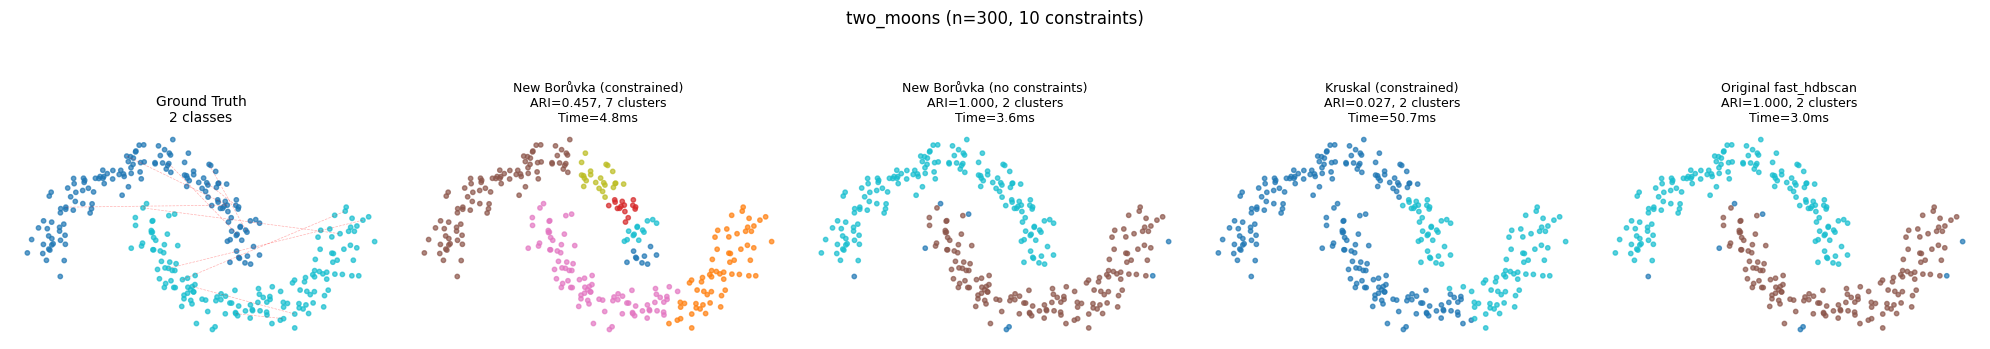

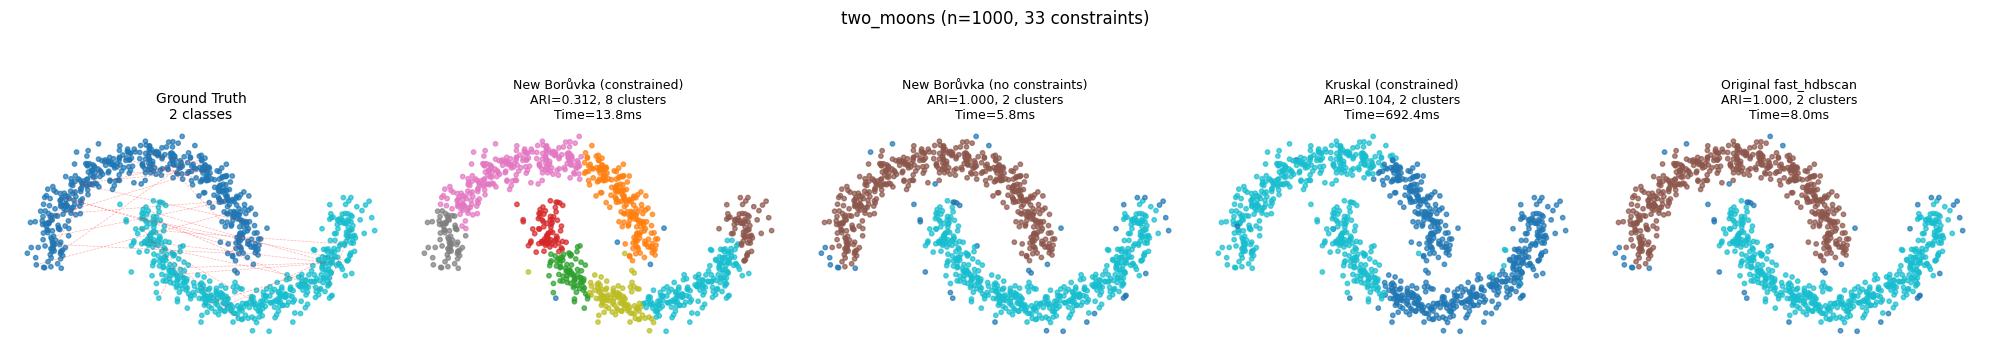


Clustering Comparison: spiral


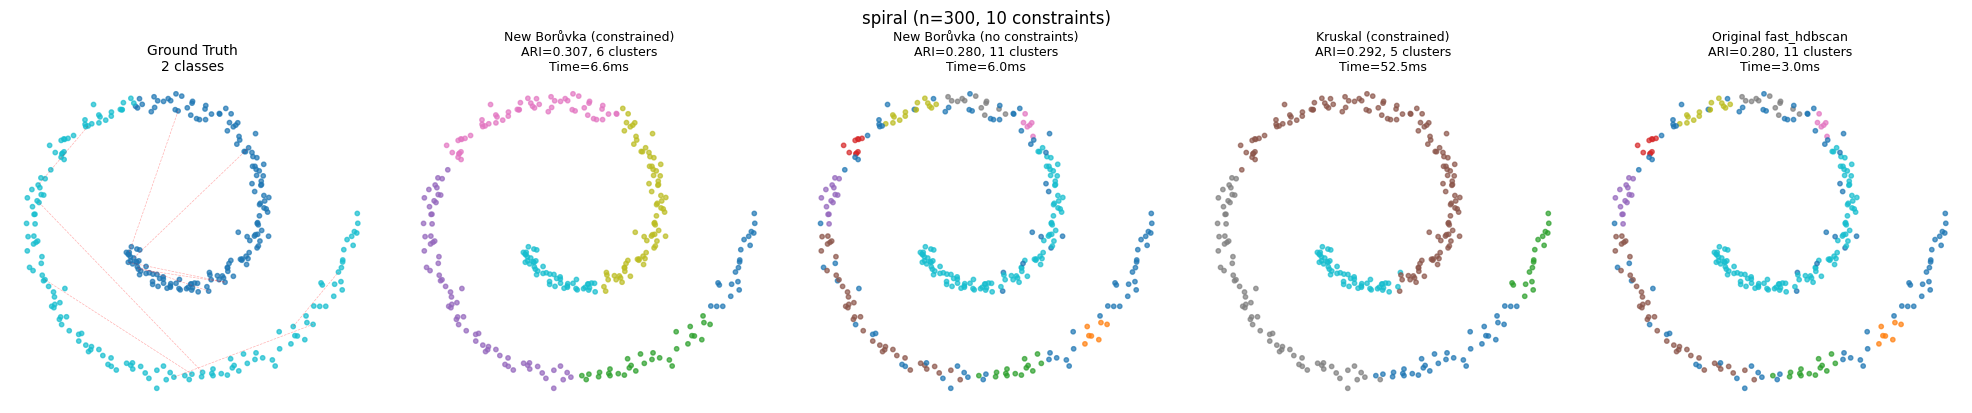

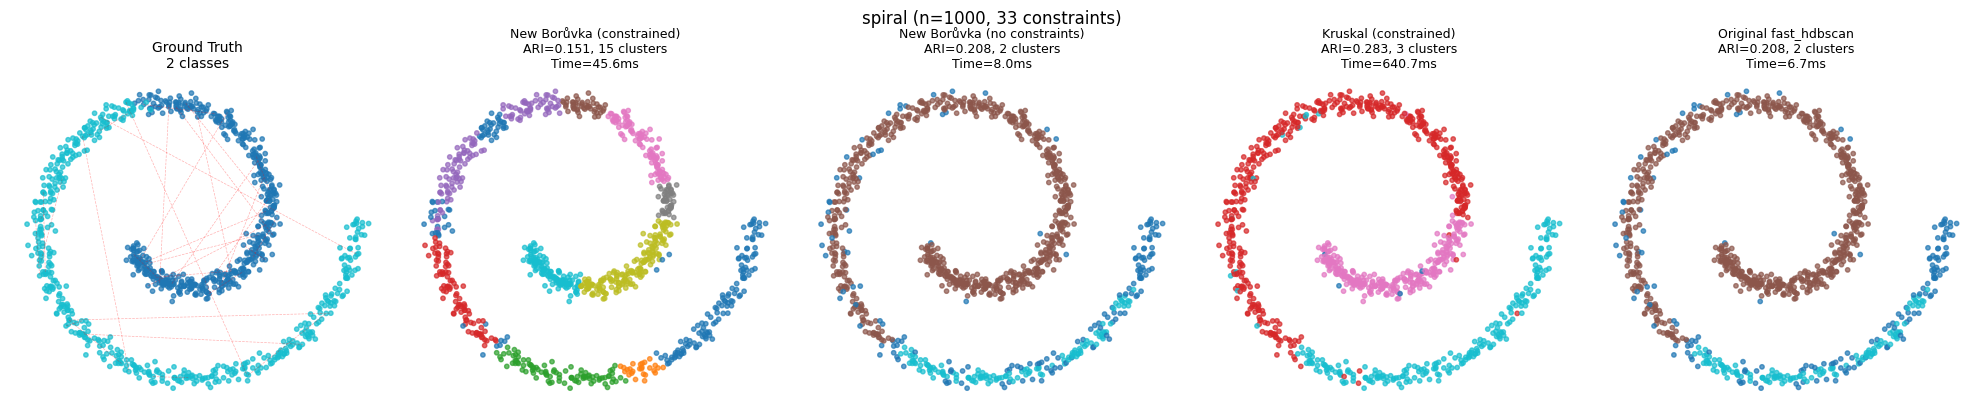


Clustering Comparison: concentric_rings


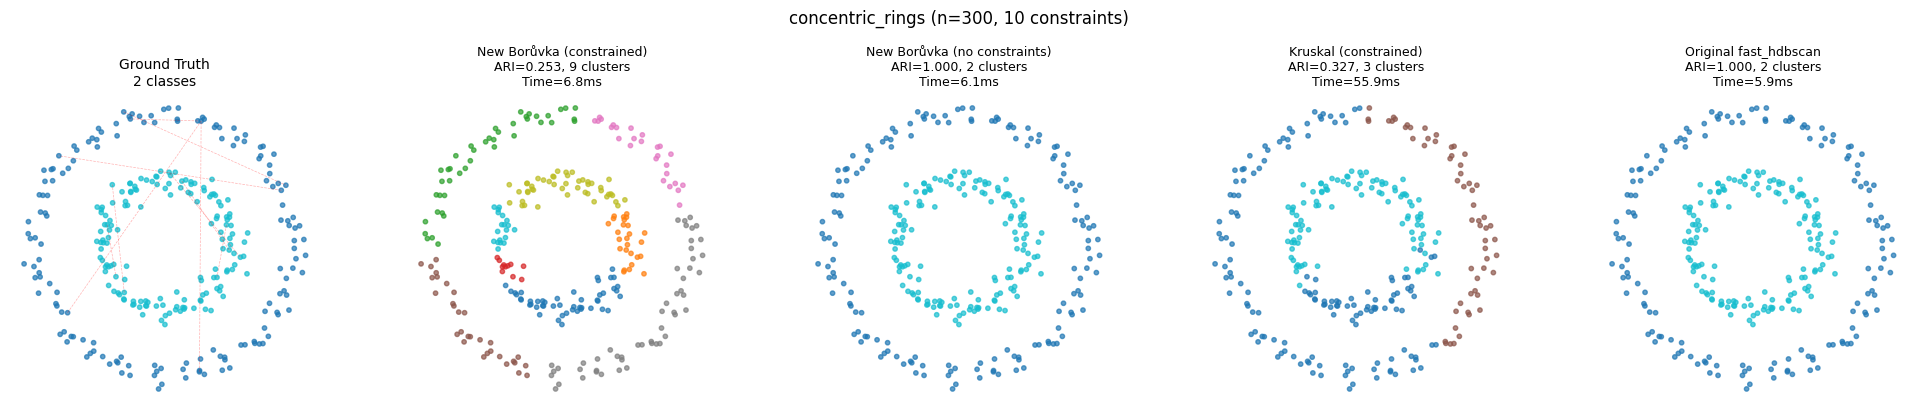

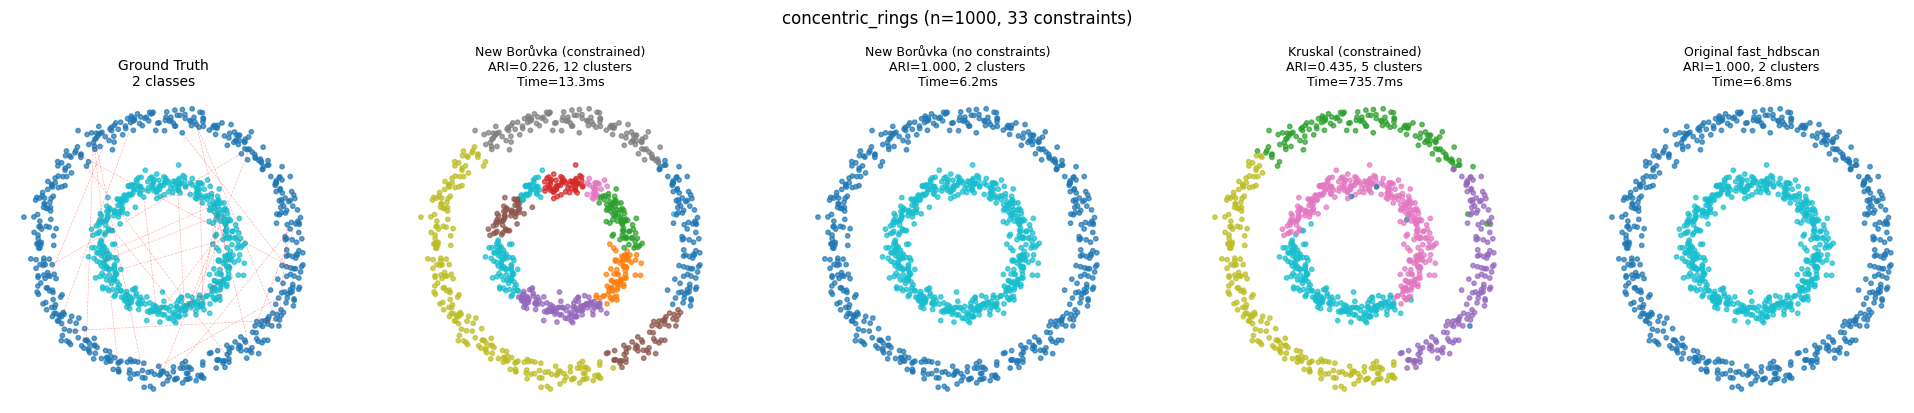


Clustering Comparison: figure_eight


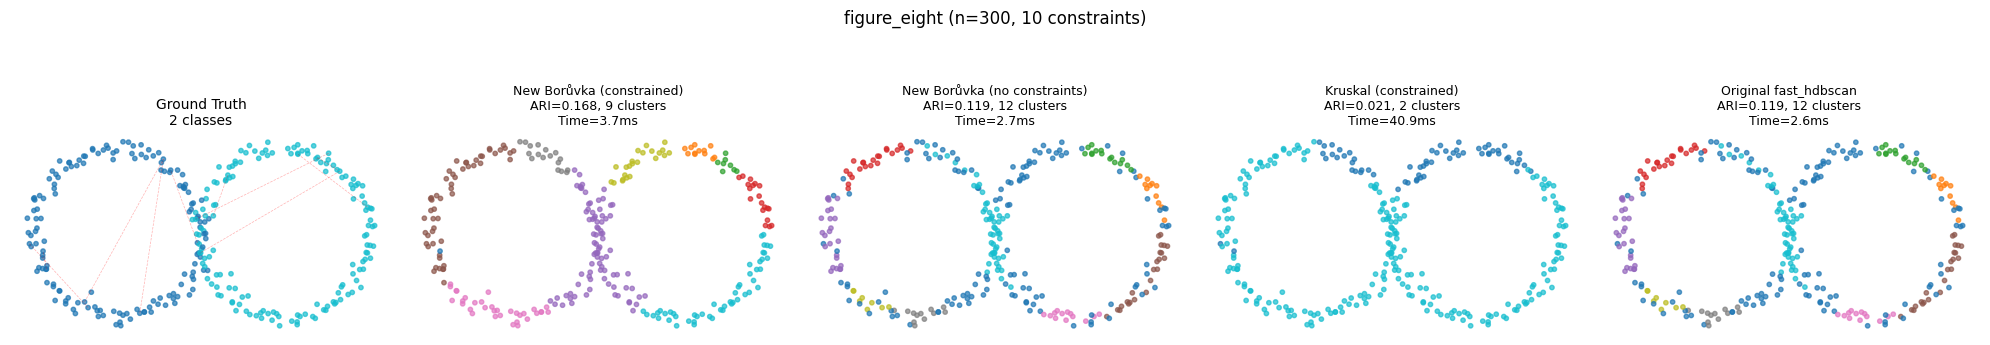

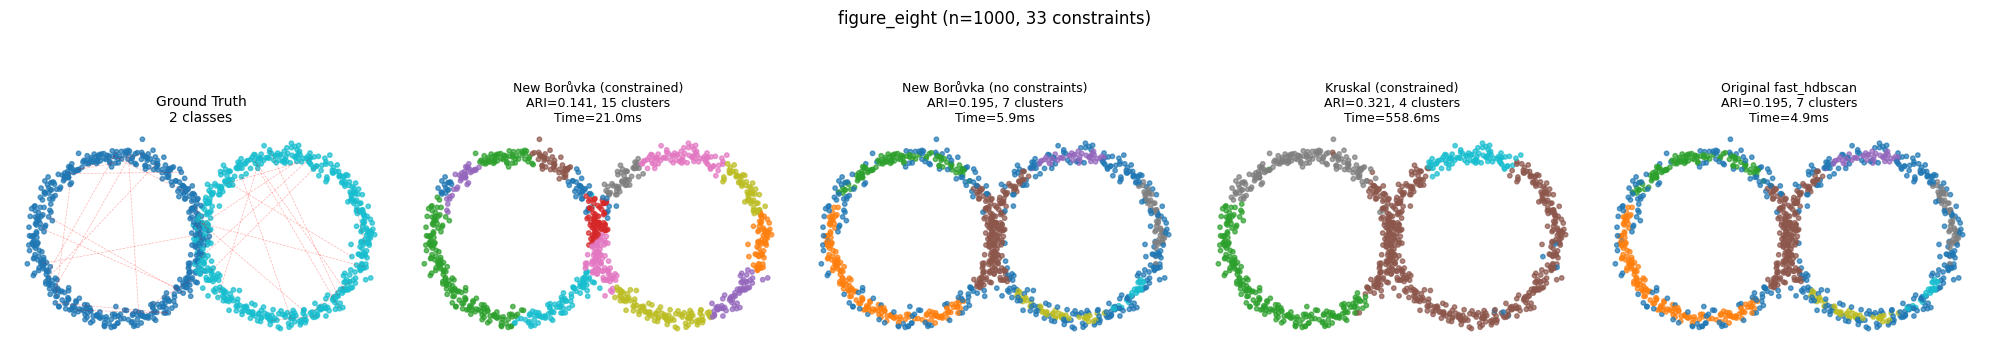


Clustering Comparison: swiss_roll


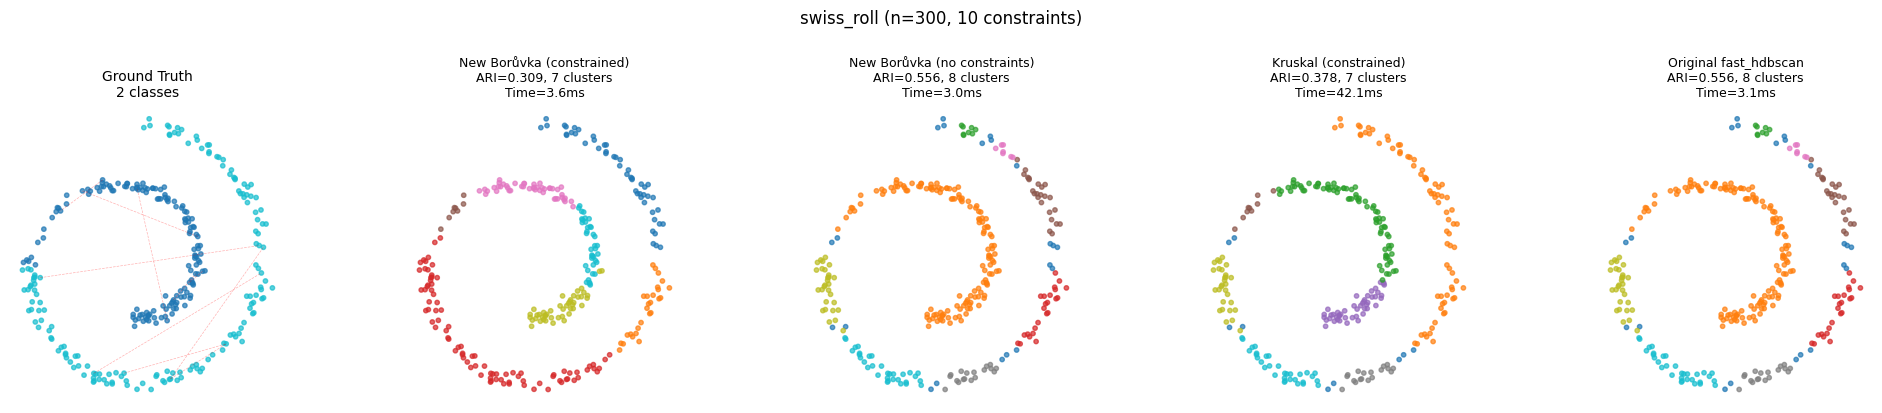

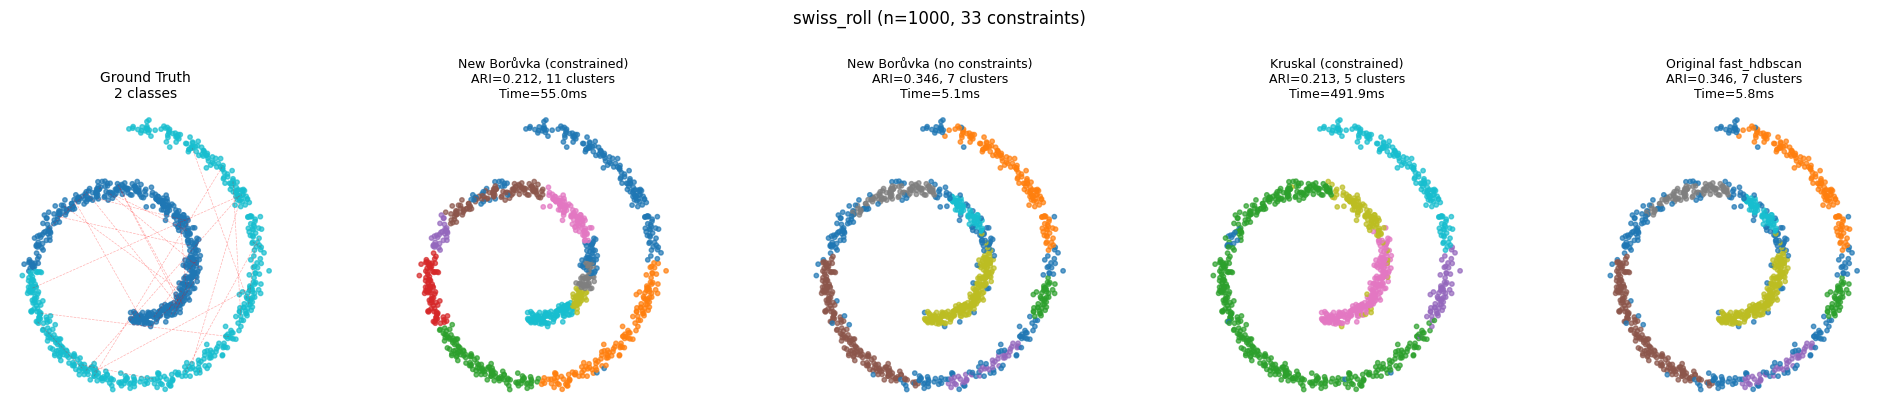


Clustering Comparison: pinwheel


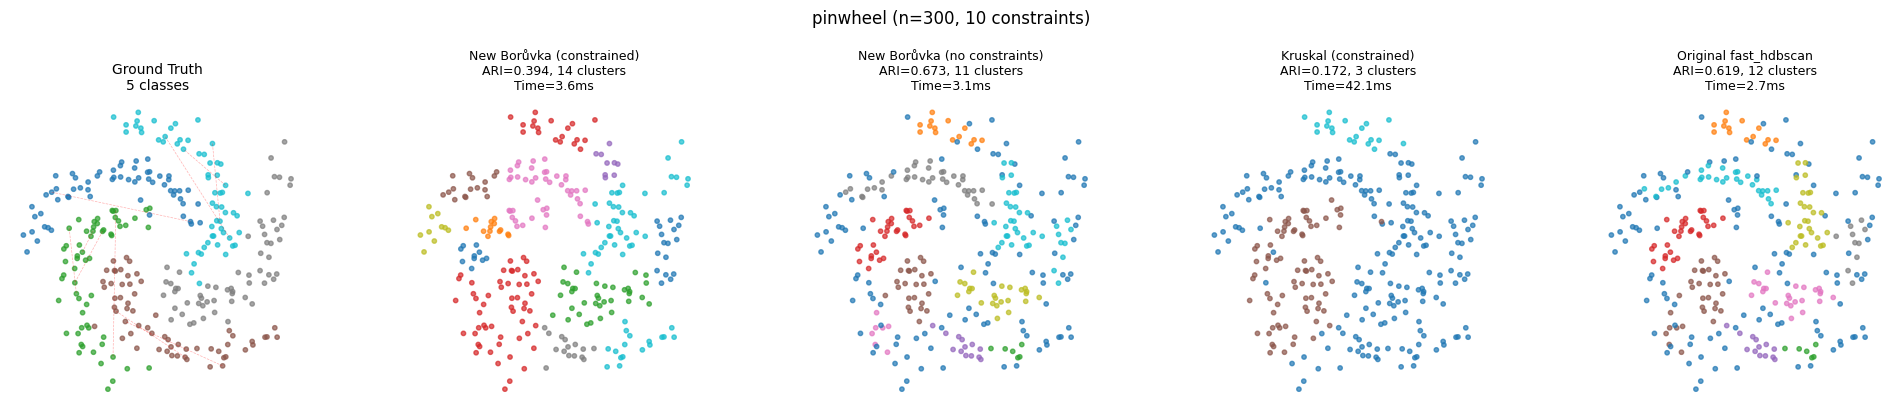

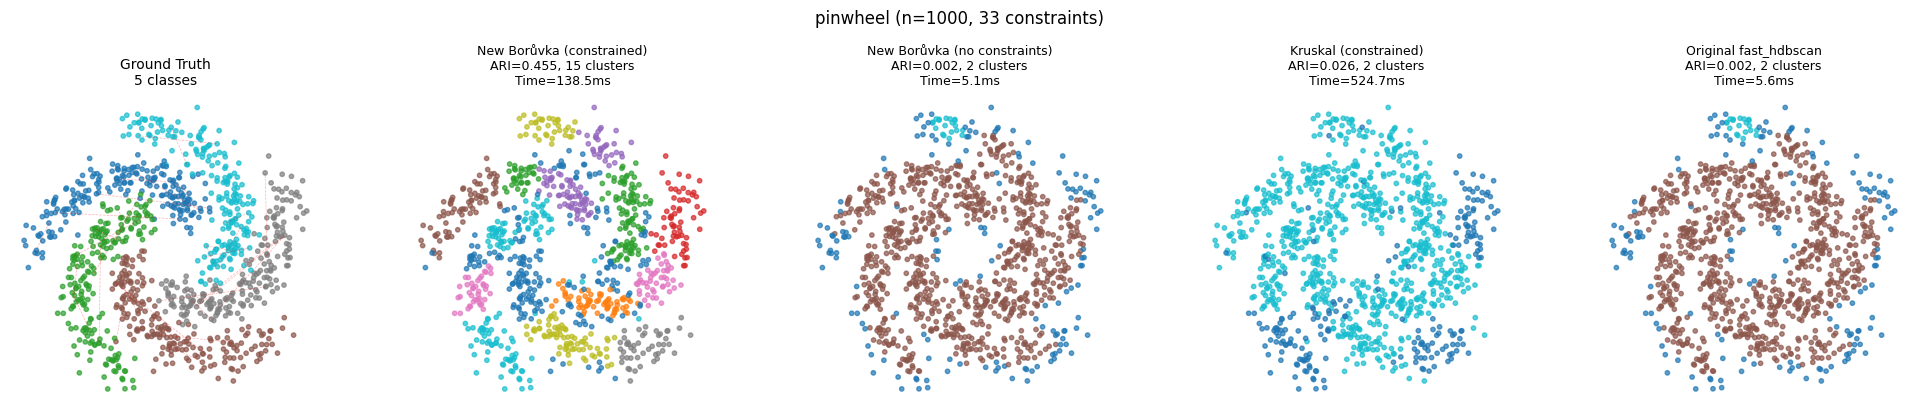


Clustering Comparison: t_shape


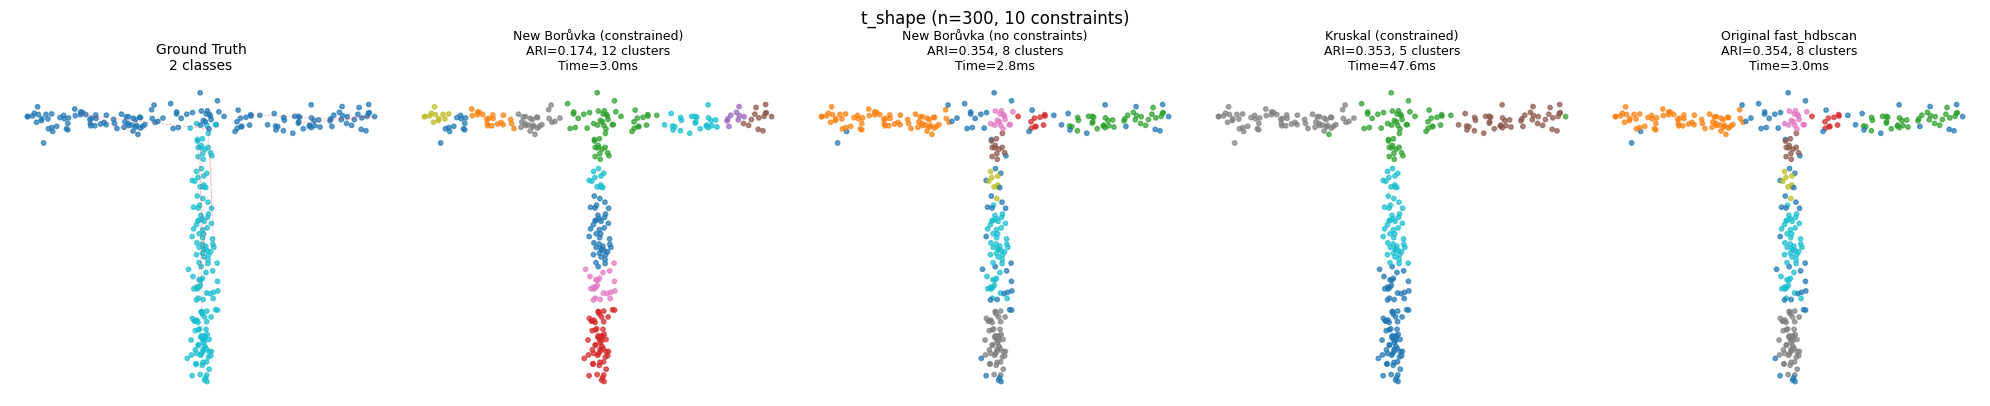

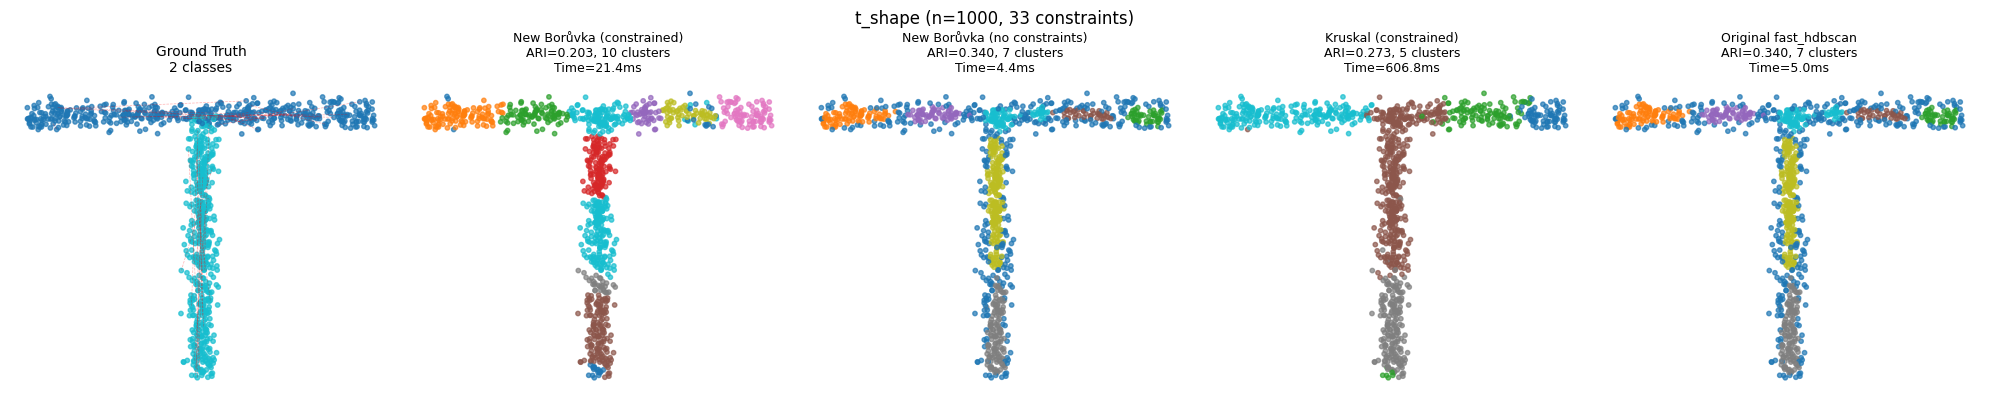

In [15]:
def plot_clustering_comparison(
    dataset_type: str,
    size: int,
    data: Dict,
    benchmark_results: Dict[str, BenchmarkResult],
    figsize: Tuple[int, int] = (20, 4),
) -> None:
    """
    Plot side-by-side comparison of clustering results from different methods.
    
    Args:
        dataset_type: Name of the dataset type.
        size: Dataset size.
        data: Dataset dictionary with X, y, constraints.
        benchmark_results: Dictionary of BenchmarkResult objects.
        figsize: Figure size.
    """
    X = data['X']
    y_true = data['y']
    constraints = data['constraints']
    
    # Determine number of plots (ground truth + methods)
    methods = list(benchmark_results.keys())
    n_plots = 1 + len(methods)  # Ground truth + all methods
    
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    
    # Plot ground truth
    ax = axes[0]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(f"Ground Truth\n{len(np.unique(y_true))} classes", fontsize=10)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Plot constraints as dashed lines
    if len(constraints) > 0 and len(constraints) <= 50:
        for i, j in constraints:
            ax.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]], 
                   'r--', alpha=0.3, linewidth=0.5)
    
    # Plot each method's result
    for idx, (method_key, result) in enumerate(benchmark_results.items()):
        ax = axes[idx + 1]
        
        if result.error:
            ax.text(0.5, 0.5, f"Error:\n{result.error}", 
                   ha='center', va='center', transform=ax.transAxes, fontsize=8)
            ax.set_title(f"{result.method_name}\nERROR", fontsize=10)
        else:
            labels = result.labels
            # Handle noise points (label -1) with gray color
            colors = np.where(labels >= 0, labels, -1)
            scatter = ax.scatter(X[:, 0], X[:, 1], c=colors, cmap='tab10', s=10, alpha=0.7)
            
            title = (f"{result.method_name}\n"
                    f"ARI={result.ari_score:.3f}, {result.n_clusters} clusters\n"
                    f"Time={result.time_seconds*1000:.1f}ms")
            ax.set_title(title, fontsize=9)
        
        ax.set_aspect('equal')
        ax.axis('off')
    
    plt.suptitle(f"{dataset_type} (n={size}, {len(constraints)} constraints)", 
                fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


# Plot comparisons for each dataset type at selected visualization sizes
PLOT_SIZES = [300, 1000]  # Show two representative sizes

for dataset_type in datasets.keys():
    print(f"\n{'='*60}")
    print(f"Clustering Comparison: {dataset_type}")
    print(f"{'='*60}")
    
    for size in PLOT_SIZES:
        if size in all_benchmarks.get(dataset_type, {}):
            plot_clustering_comparison(
                dataset_type,
                size,
                datasets[dataset_type][size],
                all_benchmarks[dataset_type][size],
            )

## 6. Metrics Summary Table

Comprehensive table showing ARI, NMI, V-measure, and timing for all methods.

In [16]:
def print_metrics_table(all_benchmarks: Dict) -> None:
    """Print comprehensive metrics table for all benchmarks."""
    
    for dataset_type, size_results in all_benchmarks.items():
        print(f"\n{'='*100}")
        print(f"METRICS SUMMARY: {dataset_type}")
        print(f"{'='*100}")
        
        # Header
        header = f"{'Size':>6} | {'Method':<35} | {'ARI':>6} | {'NMI':>6} | {'V-Measure':>9} | {'Time(ms)':>10} | {'Clusters':>8} | {'Noise':>6}"
        print(header)
        print("-" * len(header))
        
        for size in sorted(size_results.keys()):
            results = size_results[size]
            for method_key, result in results.items():
                if result.error:
                    print(f"{size:>6} | {result.method_name:<35} | {'ERR':>6} | {'ERR':>6} | {'ERR':>9} | {'N/A':>10} | {'N/A':>8} | {'N/A':>6}")
                else:
                    print(f"{size:>6} | {result.method_name:<35} | {result.ari_score:>6.3f} | {result.nmi_score:>6.3f} | {result.v_measure:>9.3f} | {result.time_seconds*1000:>10.1f} | {result.n_clusters:>8} | {result.n_noise:>6}")
            print("-" * len(header))


print_metrics_table(all_benchmarks)


METRICS SUMMARY: two_moons
  Size | Method                              |    ARI |    NMI | V-Measure |   Time(ms) | Clusters |  Noise
-----------------------------------------------------------------------------------------------------------
   100 | New Borůvka (constrained)           |  0.235 |  0.489 |     0.489 |        5.5 |        9 |      0
   100 | New Borůvka (no constraints)        |  0.659 |  0.638 |     0.638 |        5.3 |        4 |     20
   100 | Kruskal (constrained)               |  0.224 |  0.280 |     0.280 |        7.6 |        2 |      0
   100 | Original fast_hdbscan               |  0.659 |  0.638 |     0.638 |        1.8 |        4 |     20
-----------------------------------------------------------------------------------------------------------
   300 | New Borůvka (constrained)           |  0.457 |  0.596 |     0.596 |        4.8 |        7 |      0
   300 | New Borůvka (no constraints)        |  1.000 |  1.000 |     1.000 |        3.6 |        2 |      8


## 7. Scaling Analysis (100 → 1,000 points)

Run timing benchmarks across all 7 geometry types and all 4 methods.

| Method | Key |
|--------|-----|
| New Borůvka (constrained) | `new_boruvka_cl` |
| New Borůvka (no constraints) | `new_boruvka_nocl` |
| Kruskal (constrained) | `kruskal_cl` |
| Original fast_hdbscan | `original` |

In [17]:
# Generate datasets for scaling analysis using ALL geometries
SCALING_SIZES = SIZES  # [100, 200, ..., 1000]

METHOD_KEYS = ['new_boruvka_cl', 'new_boruvka_nocl', 'kruskal_cl', 'original']

print("Generating datasets for scaling analysis...")
print(f"Sizes: {SCALING_SIZES}")
print(f"Geometries: {list(datasets.keys())}")
print("(Estimated time: 2-4 minutes)\n")

full_scale_datasets = generate_all_datasets(SCALING_SIZES)
print(f"\nGenerated {len(SCALING_SIZES)} sizes × {len(full_scale_datasets)} geometries!")

# ── Run scaling benchmarks ──
print("\n" + "="*80)
print("RUNNING SCALING BENCHMARKS (All Geometries × 4 Methods)")
print("="*80)

scaling_results_by_geometry = {}
import time as time_module
start_time = time_module.perf_counter()

for geometry_name in full_scale_datasets.keys():
    print(f"\n{'='*60}")
    print(f"Geometry: {geometry_name}")
    print(f"{'='*60}")

    scaling_results_by_geometry[geometry_name] = {
        k: {'sizes': [], 'times': [], 'ari': []} for k in METHOD_KEYS
    }

    for size in SCALING_SIZES:
        data = full_scale_datasets[geometry_name][size]
        mcs = max(5, size // 50)
        ms = mcs

        # 1. New Borůvka constrained
        r = run_new_boruvka_constrained(
            data['X'], data['cl_indptr'], data['cl_indices'], data['y'], mcs, ms)
        scaling_results_by_geometry[geometry_name]['new_boruvka_cl']['sizes'].append(size)
        scaling_results_by_geometry[geometry_name]['new_boruvka_cl']['times'].append(r.time_seconds)
        scaling_results_by_geometry[geometry_name]['new_boruvka_cl']['ari'].append(r.ari_score)

        # 2. New Borůvka no constraints
        r = run_new_boruvka_unconstrained(data['X'], data['y'], mcs, ms)
        scaling_results_by_geometry[geometry_name]['new_boruvka_nocl']['sizes'].append(size)
        scaling_results_by_geometry[geometry_name]['new_boruvka_nocl']['times'].append(r.time_seconds)
        scaling_results_by_geometry[geometry_name]['new_boruvka_nocl']['ari'].append(r.ari_score)

        # 3. Kruskal constrained
        r = run_kruskal_constrained(
            data['distances'], data['constraint_matrix'], data['y'], mcs, ms)
        scaling_results_by_geometry[geometry_name]['kruskal_cl']['sizes'].append(size)
        scaling_results_by_geometry[geometry_name]['kruskal_cl']['times'].append(r.time_seconds)
        scaling_results_by_geometry[geometry_name]['kruskal_cl']['ari'].append(r.ari_score)

        # 4. Original fast_hdbscan
        r = run_original_fast_hdbscan(data['X'], data['y'], mcs, ms)
        scaling_results_by_geometry[geometry_name]['original']['sizes'].append(size)
        scaling_results_by_geometry[geometry_name]['original']['times'].append(r.time_seconds)
        scaling_results_by_geometry[geometry_name]['original']['ari'].append(r.ari_score)

    # Summary for this geometry
    for k in METHOD_KEYS:
        last = scaling_results_by_geometry[geometry_name][k]['times'][-1]
        print(f"  {k:25s}: {last*1000:>8.1f} ms at n={SCALING_SIZES[-1]}")

elapsed = time_module.perf_counter() - start_time
print(f"\n{'='*80}")
print(f"SCALING BENCHMARKS COMPLETE! Total time: {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"{'='*80}")

Generating datasets for scaling analysis...
Sizes: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
Geometries: ['two_moons', 'spiral', 'concentric_rings', 'figure_eight', 'swiss_roll', 'pinwheel', 't_shape']
(Estimated time: 2-4 minutes)

Generated datasets for size 500
Generated datasets for size 1000

Generated 10 sizes × 7 geometries!

RUNNING SCALING BENCHMARKS (All Geometries × 4 Methods)

Geometry: two_moons
  new_boruvka_cl           :     12.4 ms at n=1000
  new_boruvka_nocl         :      5.4 ms at n=1000
  kruskal_cl               :    540.1 ms at n=1000
  original                 :      6.4 ms at n=1000

Geometry: spiral
  new_boruvka_cl           :     39.4 ms at n=1000
  new_boruvka_nocl         :      5.3 ms at n=1000
  kruskal_cl               :    508.2 ms at n=1000
  original                 :      6.8 ms at n=1000

Geometry: concentric_rings
  new_boruvka_cl           :     11.8 ms at n=1000
  new_boruvka_nocl         :      6.8 ms at n=1000
  kruskal_cl          

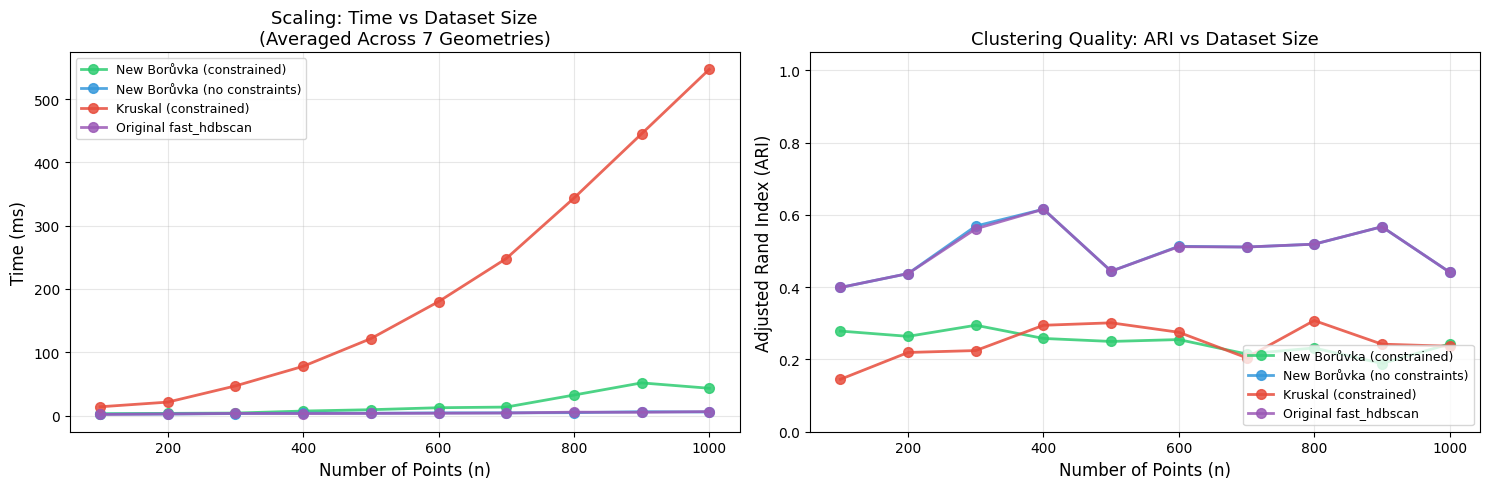


SCALING SUMMARY (Averaged Across All 7 Geometries)
  Size | NewBorůvka+CL(ms) | NewBorůvka(ms) |  Kruskal+CL(ms) |  Original(ms) | NewBorůvka ARI
-----------------------------------------------------------------------------------------------
   100 |               2.9 |            2.1 |            13.8 |           1.7 |          0.278
   200 |               3.4 |            2.4 |            21.2 |           2.5 |          0.264
   300 |               3.9 |            3.1 |            46.8 |           3.3 |          0.295
   400 |               7.1 |            3.8 |            77.7 |           3.1 |          0.258
   500 |               9.2 |            3.7 |           121.5 |           3.3 |          0.250
   600 |              12.3 |            4.2 |           179.9 |           3.6 |          0.255
   700 |              13.4 |            4.2 |           247.9 |           4.0 |          0.215
   800 |              32.3 |            4.5 |           343.4 |           5.3 |          0.2

In [18]:
# ── Aggregate results across all geometries and plot ──
sizes = SCALING_SIZES

COLORS = {
    'new_boruvka_cl':    '#2ecc71',
    'new_boruvka_nocl':  '#3498db',
    'kruskal_cl':        '#e74c3c',
    'original':          '#9b59b6',
}
LABELS = {
    'new_boruvka_cl':    'New Borůvka (constrained)',
    'new_boruvka_nocl':  'New Borůvka (no constraints)',
    'kruskal_cl':        'Kruskal (constrained)',
    'original':          'Original fast_hdbscan',
}

# Aggregate means across geometries
aggregated = {k: {'times': [], 'ari': []} for k in METHOD_KEYS}

for i, size in enumerate(sizes):
    for k in METHOD_KEYS:
        t_list, a_list = [], []
        for geo in scaling_results_by_geometry:
            t_list.append(scaling_results_by_geometry[geo][k]['times'][i])
            a_list.append(scaling_results_by_geometry[geo][k]['ari'][i])
        aggregated[k]['times'].append(np.mean(t_list))
        aggregated[k]['ari'].append(np.mean(a_list))

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Time vs Size
ax = axes[0]
for k in METHOD_KEYS:
    ax.plot(sizes, [t * 1000 for t in aggregated[k]['times']],
            'o-', markersize=7, linewidth=2,
            color=COLORS[k], label=LABELS[k], alpha=0.85)
ax.set_xlabel('Number of Points (n)', fontsize=12)
ax.set_ylabel('Time (ms)', fontsize=12)
ax.set_title('Scaling: Time vs Dataset Size\n(Averaged Across 7 Geometries)', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# ARI vs Size
ax = axes[1]
for k in METHOD_KEYS:
    ax.plot(sizes, aggregated[k]['ari'],
            'o-', markersize=7, linewidth=2,
            color=COLORS[k], label=LABELS[k], alpha=0.85)
ax.set_xlabel('Number of Points (n)', fontsize=12)
ax.set_ylabel('Adjusted Rand Index (ARI)', fontsize=12)
ax.set_title('Clustering Quality: ARI vs Dataset Size', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# ── Summary table ──
print("\n" + "="*95)
print("SCALING SUMMARY (Averaged Across All 7 Geometries)")
print("="*95)
header = (f"{'Size':>6} | {'NewBorůvka+CL(ms)':>17} | {'NewBorůvka(ms)':>14} | "
          f"{'Kruskal+CL(ms)':>15} | {'Original(ms)':>13} | {'NewBorůvka ARI':>14}")
print(header)
print("-"*95)

for i, size in enumerate(sizes):
    nb_cl = aggregated['new_boruvka_cl']['times'][i] * 1000
    nb_no = aggregated['new_boruvka_nocl']['times'][i] * 1000
    kr_cl = aggregated['kruskal_cl']['times'][i] * 1000
    orig  = aggregated['original']['times'][i] * 1000
    ari   = aggregated['new_boruvka_cl']['ari'][i]
    print(f"{size:>6} | {nb_cl:>17.1f} | {nb_no:>14.1f} | {kr_cl:>15.1f} | {orig:>13.1f} | {ari:>14.3f}")

## Summary

This notebook benchmarks **4 HDBSCAN methods** across **7 challenging geometric datasets** with **intra-class** (adversarial) cannot-link constraints.

### Datasets (7 Geometry Types)
1. **Two Moons** — classic non-convex benchmark
2. **Spiral** — Archimedean spiral (elongated topology)
3. **Concentric Rings** — nested circles
4. **Figure-8 (Lemniscate)** — two lobes sharing a pinch point
5. **Swiss Roll (2-D)** — band-like manifold
6. **Pinwheel** — galaxy-arm clusters
7. **T-Shape** — stem + crossbar junction

### Method Comparisons (4 Algorithms)
| # | Method | MST | Constraints | Input |
|---|--------|-----|-------------|-------|
| 1 | **New Borůvka (constrained)** | `boruvka_constrained_new.py` | ✅ CL | KD-tree |
| 2 | **New Borůvka (no constraints)** | same code, empty CSR | ❌ | KD-tree |
| 3 | **Kruskal (constrained)** | `hdbscan_cannotLink.py` | ✅ CL | precomputed |
| 4 | **Original fast_hdbscan** | `boruvka.py` | ❌ | KD-tree |

### Performance Metrics
- **Clustering Quality**: ARI, NMI, V-measure vs ground truth
- **Scalability**: 100 → 1,000 points (10 sizes × 7 geometries = 70 trials per method)
- **Speed**: Wall-clock time including KD-tree build + MST + cluster extraction